## 1. Importing Required Libraries

In this cell, I import all the libraries needed for the project.
I suppress warnings to keep the notebook clean and readable.


In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit   
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
warnings.filterwarnings("ignore")


## 2. Defining Forecast Parameters

Here I define the key parameters for forecasting:

- `FORECAST_DATE`: The date for which we need to generate predictions.
- `FORECAST_HORIZON`: Since the data is recorded every 15 minutes, one full day corresponds to 96 time steps.
- `SEASONAL_PERIOD`: Also set to 96 because electricity consumption follows daily seasonality.

These values will be used throughout the notebook.


In [2]:
FORECAST_HORIZON = 96
## TIME_FREQUENCY = "15min"
FORECAST_DATE = pd.to_datetime("2010-02-19")
SEASONAL_PERIOD = 96


In [3]:
df = pd.read_excel("../data/Elec-train.xlsx")
df.head()


,Timestamp,Power (kW),Temp (C°)
0,2010-01-01 01:15:00,165.1,10.555556
1,1/1/2010 1:30,151.6,10.555556
2,1/1/2010 1:45,146.9,10.555556
3,1/1/2010 2:00,153.7,10.555556
4,1/1/2010 2:15,153.8,10.555556


In [4]:
df.shape


(4795, 3)

In [5]:
df.dtypes


Timestamp      object
Power (kW)    float64
Temp (C°)     float64
dtype: object

In [6]:
df.columns


Index(['Timestamp', 'Power (kW)', 'Temp (C°)'], dtype='str')

In [7]:
df = df.rename(columns={
    "Power (kW)": "Power_kW",
    "Temp (C°)": "Temperature"
})


In [8]:
df.columns


Index(['Timestamp', 'Power_kW', 'Temperature'], dtype='str')

In [9]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df.dtypes


Timestamp      datetime64[us]
Power_kW              float64
Temperature           float64
dtype: object

In [10]:
df = df.sort_values("Timestamp")
df = df.reset_index(drop=True)

df.head()


,Timestamp,Power_kW,Temperature
0,2010-01-01 01:15:00,165.1,10.555556
1,2010-01-01 01:30:00,151.6,10.555556
2,2010-01-01 01:45:00,146.9,10.555556
3,2010-01-01 02:00:00,153.7,10.555556
4,2010-01-01 02:15:00,153.8,10.555556


In [11]:
df.isna().sum()


Timestamp       0
Power_kW       96
Temperature     0
dtype: int64

## 6. Visualizing Electricity Consumption

In this cell, I plot the electricity consumption over time.

This helps identify:

- Daily patterns
- Seasonal effects
- Trends
- Sudden spikes



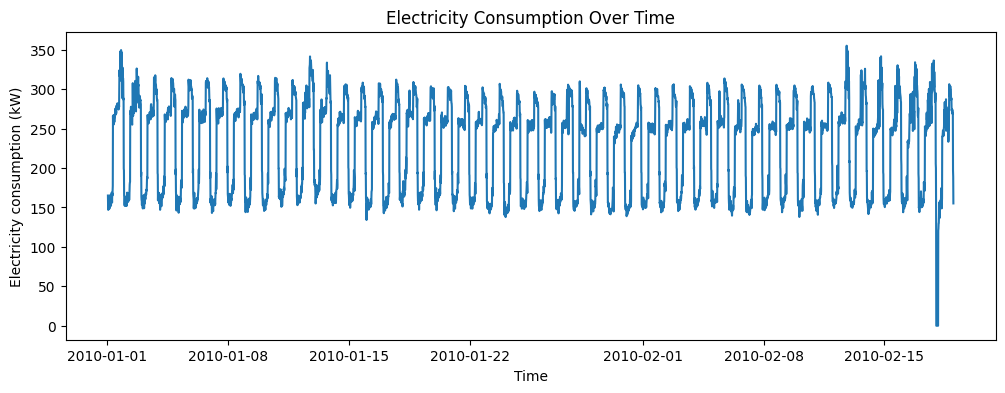

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(df["Timestamp"], df["Power_kW"])
plt.xlabel("Time")
plt.ylabel("Electricity consumption (kW)")
plt.title("Electricity Consumption Over Time")
plt.show()
plt.figure(figsize=(12, 4))


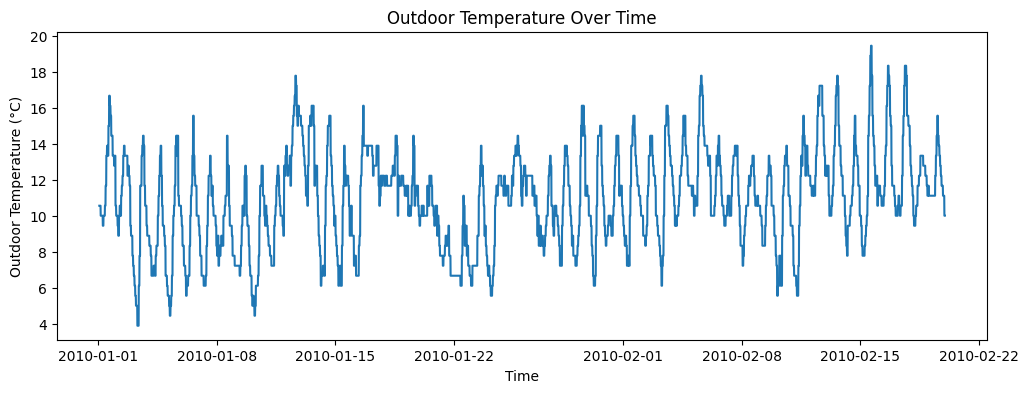

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(df["Timestamp"], df["Temperature"])
plt.xlabel("Time")
plt.ylabel("Outdoor Temperature (°C)")
plt.title("Outdoor Temperature Over Time")
plt.show()


## 7. Creating Time-Series Features

Machine learning models cannot directly understand time order, so I create additional features:

- Lag features (previous 1, 2, 3, 96, and 672 values)
- Hour of the day
- Day of the week

Lag 96 captures daily seasonality.
Lag 672 captures weekly seasonality.

In [14]:

features = df.copy()

features["lag_1"] = features["Power_kW"].shift(1)
features["lag_2"] = features["Power_kW"].shift(2)
features["lag_3"] = features["Power_kW"].shift(3)

features["lag_96"] = features["Power_kW"].shift(96)
features["lag_672"] = features["Power_kW"].shift(96 * 7)

features["hour"] = features["Timestamp"].dt.hour
features["dayofweek"] = features["Timestamp"].dt.dayofweek

features = features.dropna().reset_index(drop=True)

features.head()


,Timestamp,Power_kW,Temperature,lag_1,lag_2,lag_3,lag_96,lag_672,hour,dayofweek
0,2010-01-08 01:15:00,166.0,8.888889,161.8,162.8,156.2,164.4,165.1,1,4
1,2010-01-08 01:30:00,153.5,8.888889,166.0,161.8,162.8,151.6,151.6,1,4
2,2010-01-08 01:45:00,157.0,8.888889,153.5,166.0,161.8,143.0,146.9,1,4
3,2010-01-08 02:00:00,162.6,8.888889,157.0,153.5,166.0,147.9,153.7,2,4
4,2010-01-08 02:15:00,159.1,7.222222,162.6,157.0,153.5,155.2,153.8,2,4


In [15]:
# df["lag_1"] = df["Power_kW"].shift(1)
# df["lag_2"] = df["Power_kW"].shift(2)
# df["lag_3"] = df["Power_kW"].shift(3)
# df = df.dropna().reset_index(drop=True)

# df.head()


## 8. Preparing Training Data

In this step, the dataset is restricted to observations up to **2010-02-18 23:45**.

This ensures that:
- The model is trained only on historical data.
- The forecast for 2010-02-19 is truly out-of-sample.
- No information from the forecast day leaks into the training process.

The input feature matrix (X) is constructed using lag variables, calendar features, and temperature.  
The target variable (y) corresponds to electricity consumption (Power_kW).

TimeSeriesSplit is used for cross-validation.  
Unlike standard K-fold cross-validation, it preserves chronological order and mimics a real forecasting scenario by training on past data and validating on future data.

This guarantees that future observations are never used to predict the past, ensuring a realistic and unbiased evaluation.


In [16]:
# Explicitly stop training at 2010-02-18 23:45
train_data = features[
    features["Timestamp"] <= pd.to_datetime("2010-02-18 23:45")
].copy()

feature_cols = [
    "lag_1", "lag_2", "lag_3",
    "lag_96", "lag_672",
    "Temperature",
    "hour", "dayofweek"
]

X = train_data[feature_cols]
y = train_data["Power_kW"]

tscv = TimeSeriesSplit(n_splits=3,test_size=96*2 )


## 9. Ridge Regression Model

Here I train a Ridge regression model.

I test multiple values of the regularization parameter (alpha) and evaluate performance using cross-validation.

The model with the lowest MAE is selected as the best Ridge configuration.


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import numpy as np


best_alpha = None
best_mae_ridge = np.inf
best_ridge_model = None

for alpha in [0.01, 0.1, 1, 10]:
    
    errors = []
    
    for train_idx, val_idx in tscv.split(X):
        
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Scaling inside CV (correct practice)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        
        model = Ridge(alpha=alpha)
        model.fit(X_train_scaled, y_train)
        
        predictions = model.predict(X_val_scaled)
        error = mean_absolute_error(y_val, predictions)
        errors.append(error)
        
    avg_error = np.mean(errors)
    
    if avg_error < best_mae_ridge:
        best_mae_ridge = avg_error
        best_alpha = alpha


# Train final model on full dataset
final_scaler = StandardScaler()
X_scaled_full = final_scaler.fit_transform(X)

best_ridge_model = Ridge(alpha=best_alpha)
best_ridge_model.fit(X_scaled_full, y)

print("Best Ridge Alpha:", best_alpha)
print("Best Ridge MAE:", best_mae_ridge)


Best Ridge Alpha: 10
Best Ridge MAE: 10.95641683680415


## 10. Random Forest Model

By using Random Forest Method

I tune:
- Tree depth
- Number of trees

For each combination, I compute cross-validation MAE and select the best performing model.


In [18]:
best_rf_params = None
best_mae_rf = np.inf

for depth in [5,10,15]:
    for trees in [100,200]:
        
        errors = []
        
        for train_idx, val_idx in tscv.split(X):
            
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            model = RandomForestRegressor(
                max_depth=depth,
                n_estimators=trees,
                random_state=42
            )
            
            model.fit(X_train,y_train)
            predictions = model.predict(X_val)
            errors.append(mean_absolute_error(y_val,predictions))
        
        avg_error = np.mean(errors)
        
        if avg_error < best_mae_rf:
            best_mae_rf = avg_error
            best_rf_params = (depth,trees)

print("Best RF Params:",best_rf_params)


Best RF Params: (15, 200)


## 11. XGBoost Model

XGBoost is a gradient boosting algorithm.

I tune:
- Maximum tree depth
- Learning rate

Cross-validation is used to select the best configuration.


In [19]:
best_xgb_params = None
best_mae_xgb = np.inf

for depth in [3,5]:
    for lr in [0.05,0.1]:
        
        errors = []
        
        for train_idx,val_idx in tscv.split(X):
            
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            model = XGBRegressor(
                max_depth=depth,
                learning_rate=lr,
                n_estimators=200,
                random_state=42
            )
            
            model.fit(X_train,y_train)
            predictions = model.predict(X_val)
            errors.append(mean_absolute_error(y_val,predictions))
        
        avg_error = np.mean(errors)
        
        if avg_error < best_mae_xgb:
            best_mae_xgb = avg_error
            best_xgb_params = (depth,lr)

print("Best XGB Params:",best_xgb_params)


Best XGB Params: (3, 0.1)


## 12. Support Vector Machine and Neural Network

Since SVM and MLP are sensitive to feature scaling, I first standardize the input features.

Then:

- I train an SVM model.
- I train an MLP neural network.

Both models are evaluated using time-series cross-validation.


In [20]:
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

# SVM
svm_model = SVR(C=10, epsilon=0.1)
mae_scores = []

for train_idx, val_idx in tscv.split(X):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    svm_model.fit(X_train_scaled, y_train)
    preds = svm_model.predict(X_val_scaled)
    mae_scores.append(mean_absolute_error(y_val, preds))

best_mae_svm = np.mean(mae_scores)


# MLP
mlp_model = MLPRegressor(hidden_layer_sizes=(100, 50),
                         activation='relu',
                         max_iter=500,
                         random_state=42)

mae_scores = []

for train_idx, val_idx in tscv.split(X):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    mlp_model.fit(X_train_scaled, y_train)
    preds = mlp_model.predict(X_val_scaled)
    mae_scores.append(mean_absolute_error(y_val, preds))

best_mae_mlp = np.mean(mae_scores)


## 13. Statistical Time-Series Models

In this section, I apply classical time-series models:

- Exponential Smoothing
- SARIMA

Both models use daily seasonality (96 periods).

I split the time series into training and validation parts and evaluate using MAE.


In [21]:
series_full = train_data.set_index("Timestamp")["Power_kW"]

# Exponential Smoothing Tuning

best_es_params = None
best_mae_es = np.inf

for trend in ["add", "mul"]:
    for seasonal in ["add", "mul"]:
        
        errors = []
        
        for train_idx, val_idx in tscv.split(series_full):
            
            series_train = series_full.iloc[train_idx]
            series_val = series_full.iloc[val_idx]
            
            try:
                model = ExponentialSmoothing(
                    series_train,
                    trend=trend,
                    seasonal=seasonal,
                    seasonal_periods=96
                ).fit(optimized=True)
                
                preds = model.forecast(len(series_val))
                errors.append(mean_absolute_error(series_val, preds))
            
            except:
                continue
        
        if len(errors) > 0:
            avg_error = np.mean(errors)
            
            if avg_error < best_mae_es:
                best_mae_es = avg_error
                best_es_params = (trend, seasonal)

print("Best ES Params:", best_es_params)
print("Best ES MAE:", best_mae_es)

# SARIMA Tuning 

best_sarima_params = None
best_mae_sarima = np.inf

for p in [0, 1]:
    for d in [1]:  
        for q in [0, 1]:
            
            errors = []
            
            for train_idx, val_idx in tscv.split(series_full):
                
                series_train = series_full.iloc[train_idx]
                series_val = series_full.iloc[val_idx]
                
                try:
                    model = SARIMAX(
                        series_train,
                        order=(p, d, q),
                        seasonal_order=(1, 1, 0, 96), 
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    ).fit(disp=False, maxiter=50)
                    
                    preds = model.forecast(len(series_val))
                    errors.append(mean_absolute_error(series_val, preds))
                
                except:
                    continue
            
            if len(errors) > 0:
                avg_error = np.mean(errors)
                
                if avg_error < best_mae_sarima:
                    best_mae_sarima = avg_error
                    best_sarima_params = (p, d, q)

print("Best SARIMA Params:", best_sarima_params)
print("Best SARIMA MAE:", best_mae_sarima)


Best ES Params: ('add', 'add')
Best ES MAE: 11.738667866799315
Best SARIMA Params: (0, 1, 1)
Best SARIMA MAE: 15.95527063963093


## 14. LSTM Deep Learning Model

LSTM is a recurrent neural network designed for sequence data.

Steps:
- I create sequences of 96 time steps.
- I scale the data.
- I split into training and validation sets.
- I train the LSTM model.
- I compute MAE on validation data.

This allows comparison with other models.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

sequence_length = 96

scaler = MinMaxScaler()
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

def create_sequences(data, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_len):
        X_seq.append(data[i:i+seq_len])
        y_seq.append(data[i+seq_len])
    return np.array(X_seq), np.array(y_seq)

X_lstm, y_lstm = create_sequences(y_scaled, sequence_length)

tscv = TimeSeriesSplit(n_splits=3)
mae_scores = []

for train_idx, val_idx in tscv.split(X_lstm):
    X_train, X_val = X_lstm[train_idx], X_lstm[val_idx]
    y_train, y_val = y_lstm[train_idx], y_lstm[val_idx]

    model = Sequential([
        LSTM(64, return_sequences=False, input_shape=(sequence_length, 1)),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mae')

    early_stop = EarlyStopping(patience=5, restore_best_weights=True)

    model.fit(X_train, y_train,
              validation_data=(X_val, y_val),
              epochs=50,
              batch_size=32,
              verbose=0,
              callbacks=[early_stop])

    preds = model.predict(X_val)
    preds_inv = scaler.inverse_transform(preds)
    y_val_inv = scaler.inverse_transform(y_val)

    mae_scores.append(mean_absolute_error(y_val_inv, preds_inv))
    mae_scores.append(mean_absolute_error(y_val_inv, preds_inv))

best_mae_lstm = np.mean(mae_scores)


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


## 15. Comparing All Models

In this cell, I collect the MAE scores of all models into a single table.

I sort them to identify the best performing model.

This allows objective comparison across statistical, machine learning, and deep learning approaches.


In [23]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "SVM",
        "MLP",
        "Exponential Smoothing",
        "SARIMA",
        "LSTM"
    ],
    "MAE": [
        best_mae_rf,
        best_mae_xgb,
        best_mae_svm,
        best_mae_mlp,
        best_mae_es,
        best_mae_sarima,
        best_mae_lstm
    ]
})

results.sort_values(by="MAE", inplace=True)
results


,Model,MAE
2,SVM,6.795382
3,MLP,7.103780
6,LSTM,9.418993
0,Random Forest,10.589287
1,XGBoost,10.814286
4,Exponential Smoothing,11.738668
5,SARIMA,15.955271


In [24]:
print(best_mae_rf)
print(best_mae_xgb)
print(best_mae_svm)
print(best_mae_mlp)
print(best_mae_es)
print(best_mae_sarima)
print(best_mae_lstm)


10.58928745837232
10.814285543229843
6.795381674761773
7.103780141774076
11.738667866799315
15.95527063963093
9.41899284115472


In [25]:
best_rf = RandomForestRegressor(
    max_depth=best_rf_params[0],
    n_estimators=best_rf_params[1],
    random_state=42
)

best_rf.fit(X,y)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## 17. Generating 96-Step Forecast

Since machine learning models do not automatically forecast multiple future steps, I implement recursive forecasting:

- Predict next time step
- Add prediction to dataset
- Recalculate lag features
- Repeat for 96 steps

This produces the full-day forecast for 2/19/2010.


In [26]:
lags = [1, 2, 3, 96, 672]
history = train_data.copy()
predictions = []

for i in range(FORECAST_HORIZON):
    
    last_row = history.iloc[-1]
    new_time = last_row["Timestamp"] + pd.Timedelta(minutes=15)
    
    new_row = pd.DataFrame(index=[0])
    new_row["Timestamp"] = new_time
    
    for lag in lags:
        new_row[f"lag_{lag}"] = history["Power_kW"].iloc[-lag]
    
    new_row["Temperature"] = history.iloc[-96]["Temperature"]
    new_row["hour"] = new_time.hour
    new_row["dayofweek"] = new_time.dayofweek
    
    X_input = new_row[feature_cols]
    prediction = best_rf.predict(X_input)[0]
    
    new_row["Power_kW"] = prediction
    
    history = pd.concat([history,new_row],ignore_index=True)
    predictions.append(prediction)


## 18. Exporting Final Forecast

Finally:

- I save the 96 predicted values to an Excel file.
- The file contains exactly 1 column and 96 rows.
- No index or header is included.


In [30]:
forecast_df = pd.DataFrame(predictions)

forecast_df.to_excel("JayaSaiKishore.xlsx",
                     index=False,
                     header=False)

print(forecast_df.shape)


(96, 1)
